# Gender Distribution in the United States House of Representatives  1855 - 2025

## Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(r"../data/U.S. House of Representatives Gender Distribution.csv")
df


,House Number,Total Members,Male Rep.,Male Dem.,Female Rep.,Female Dem.
0,34,234,100,83,0,0
1,35,237,90,132,0,0
2,36,238,116,83,0,0
3,37,183,108,44,0,0
4,38,241,85,72,0,0
...,...,...,...,...,...,...
81,115,435,218,130,23,64
82,116,435,186,147,13,88
83,117,435,180,132,32,90
84,118,435,188,120,34,93


When did the first woman serve in the House from the Republicans?

In [2]:
first_female_rep_house = df[df["Female Rep."] > 0]["House Number"].iloc[0]if len(df[df["Female Rep."] > 0]) > 0 else None

print(f"First Female Republican appeared in House: {first_female_rep_house}")

First Female Republican appeared in House: 65


When did the first woman serve in the House from the Democrats?

In [ ]:
first_female_dem_house = df[df["Female Dem."] > 0]["House Number"].iloc[0] if len(df[df["Female Rep."] > 0]) > 0 else None

print(f"First Female Democrat appeared in House: {first_female_dem_house}")

First Female Democrat appeared in House: 69


In [4]:
df["Total Female Reps"] = df["Female Rep."] + df["Female Dem."]
df["Total Male Reps"] = df["Male Rep."] + df["Male Dem."]
df

,House Number,Total Members,Male Rep.,Male Dem.,Female Rep.,Female Dem.,Total Female Reps,Total Male Reps
0,34,234,100,83,0,0,0,183
1,35,237,90,132,0,0,0,222
2,36,238,116,83,0,0,0,199
3,37,183,108,44,0,0,0,152
4,38,241,85,72,0,0,0,157
...,...,...,...,...,...,...,...,...
81,115,435,218,130,23,64,87,348
82,116,435,186,147,13,88,101,333
83,117,435,180,132,32,90,122,312
84,118,435,188,120,34,93,127,308


## Visualizations

* What is the most women serving in the House at one time?
* How has the number of women serving in the House trended overall?
* When did the first woman serve in the House from either party?
    * When did the first woman serve in the House from the Democrats?
    * What is the most Democrat women serving in the House at one time?
    * What is the most Republican women serving in the House at one time?
    * When did the first woman serve in the House from the Republicans?  


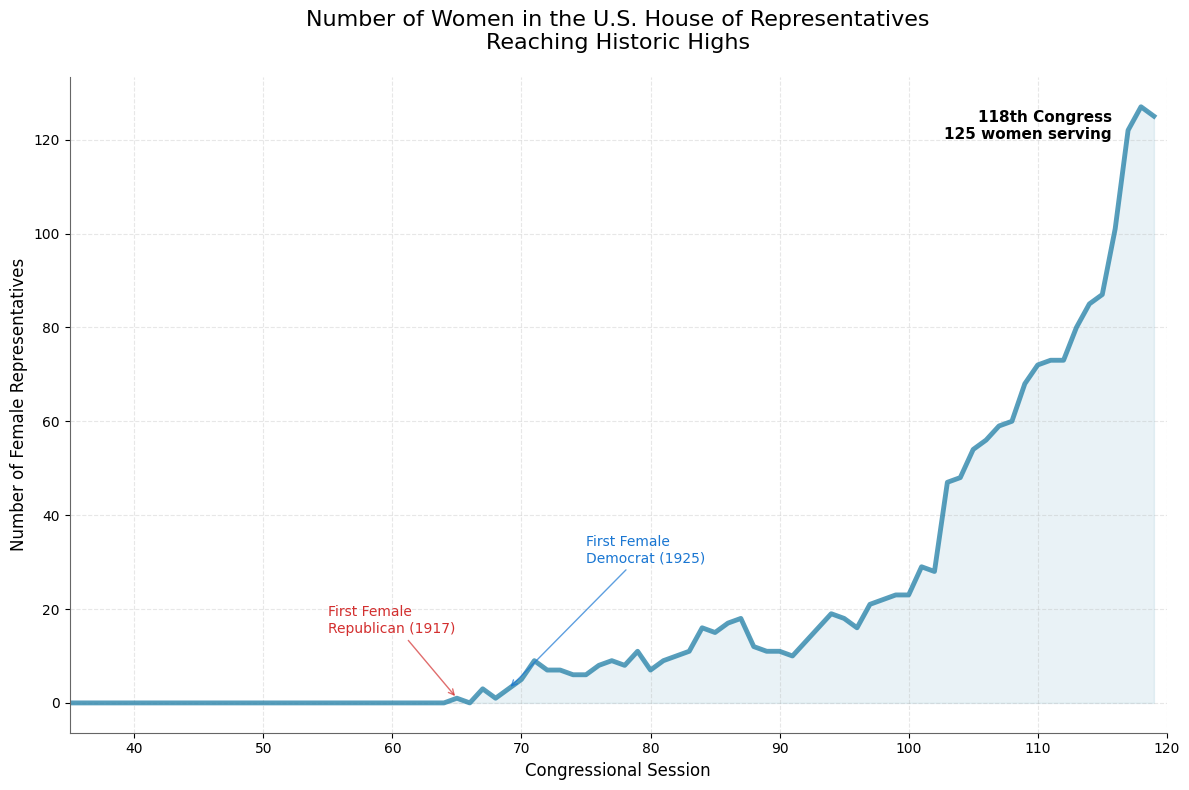

In [9]:
plt.figure(figsize=(12,8))

x = df["House Number"]
y = df["Total Female Reps"]

plt.plot(x, y, 
        linewidth = 3.5,
        color = "#2e86ab",
        alpha = 0.8,
)

plt.fill_between(x, y, 
                alpha = 0.1, 
                color = "#2e86ab",
                )

plt.xlabel("Congressional Session", fontsize = 12, fontweight = "medium")
plt.ylabel("Number of Female Representatives", fontsize = 12, fontweight = "medium")
plt.title("Number of Women in the U.S. House of Representatives\nReaching Historic Highs", fontsize = 16, pad = 20)

plt.grid(True, 
        alpha = 0.3, 
        linestyle = "--", 
        )

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
# 🤘🤘🤘
ax.spines["left"].set_color("#666666")
ax.spines["bottom"].set_color("#666666")

rep_color = "#d32f2f"
dem_color = "#1976d2"
highlight_color = "#388e3c"

milestone_houses = [65, 69, 118]
milestone_values = [df[df["House Number"] == h]["Total Female Reps"].iloc[0] for h in milestone_houses]

ax.annotate("First Female\nRepublican (1917)",
        xy = (65, milestone_values[0]), 
        xytext = (55, 15),
        color = rep_color,
        fontsize = 10,
        fontweight = "medium",
        arrowprops = dict(arrowstyle = "->", color = rep_color, alpha = 0.7)
        )

ax.annotate("First Female\nDemocrat (1925)",
        xy = (69, milestone_values[1]),
        xytext = (75, 30),
        color = dem_color,
        fontsize = 10,
        fontweight = "medium",
        arrowprops = dict(arrowstyle = "->", color = dem_color, alpha = 0.7)
        )

ax.text(0.95, 0.95, 
        f"118th Congress\n125 women serving",
        transform = ax.transAxes, fontsize = 11, fontweight = "bold",
        ha = "right",
        va="top",
        )

plt.xlim(35, 120)

plt.tight_layout()
plt.savefig('../plots/total_women_historic_line_chart.png')
plt.show()

* How has the number of women from the Democrat party serving in the House trended?
* How has the number of women from the Republican party serving in the House trended?


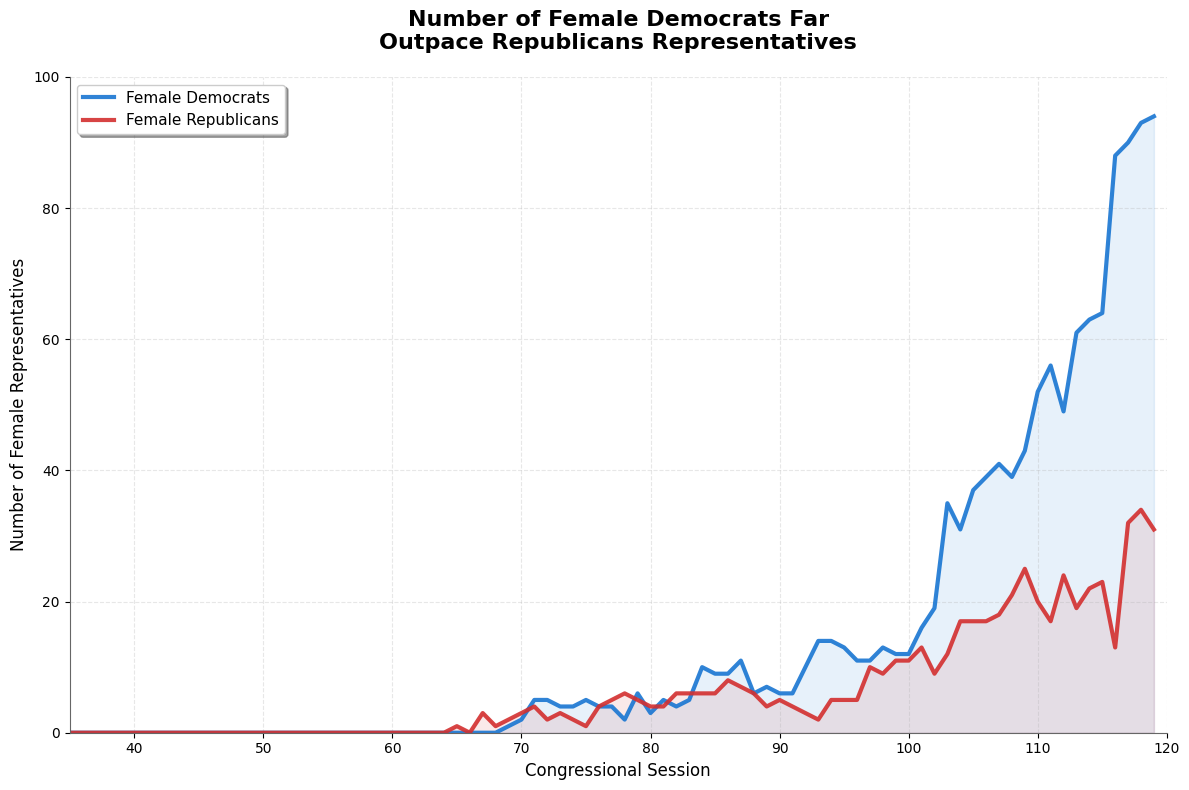

In [10]:
plt.figure(figsize=(12,8))

x = df["House Number"]
dems = df["Female Dem."]
repubs = df["Female Rep."]

plt.plot(x, dems, 
        linewidth = 3, 
        color = dem_color, 
        label = "Female Democrats",
        alpha = 0.9,
        )
plt.plot(x, repubs,
        linewidth = 3,
        color = rep_color,
        label = "Female Republicans",
        alpha = 0.9,
        )
        

plt.fill_between(x, dems,
                alpha = 0.1, 
                color = dem_color,
                )
plt.fill_between(x, repubs,
                alpha = 0.1,
                color = rep_color,
                )

plt.title("Number of Female Democrats Far\nOutpace Republicans Representatives", fontsize = 16, fontweight = "bold", pad = 20)
plt.xlabel("Congressional Session", fontsize = 12, fontweight = "medium")
plt.ylabel("Number of Female Representatives", fontsize = 12, fontweight = "medium")

plt.grid(True,
        alpha = 0.3, 
        linestyle = "--",
        )
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#666666")
ax.spines["bottom"].set_color("#666666")

plt.legend(loc = "upper left", 
                frameon = True, 
                fancybox = True, 
                shadow = True, 
                fontsize = 11,
                )

plt.xlim(35, 120)
plt.ylim(0, 100)

plt.tight_layout()
plt.savefig('../plots/totals_per_party_line_chart.png')
plt.show()


* What is the gender breakdown of the last House session?

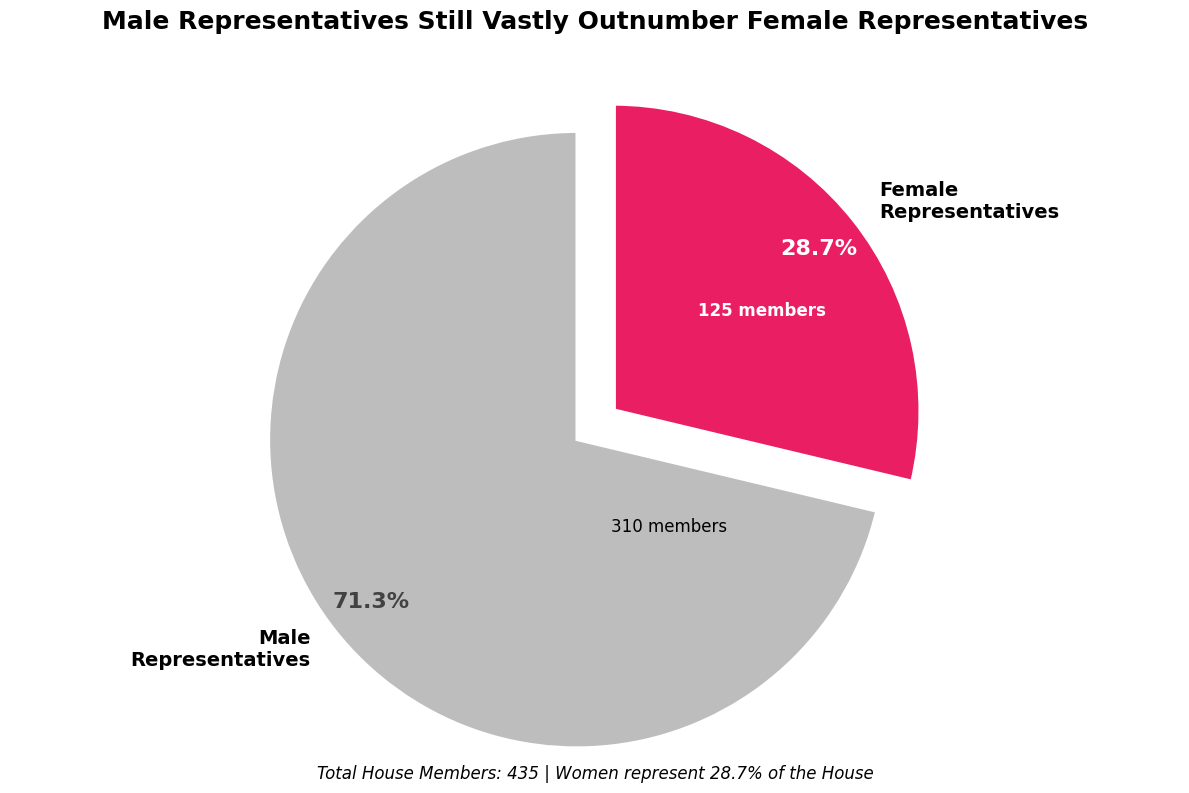

In [11]:
plt.figure(figsize=(12,8))

latest_house = df.iloc[-1]
total_females = latest_house["Female Rep."] + latest_house["Female Dem."]
total_males = latest_house["Male Rep."] + latest_house["Male Dem."]

sizes = [total_males, total_females]
labels = ["Male\nRepresentatives", "Female\nRepresentatives"]
colors = ["#bdbdbd", "#e91e63"]

explode = (0, 0.15)
wedges, texts, autotexts = plt.pie(sizes, 
                                    labels = labels,
                                    colors = colors,
                                    explode = explode,
                                    autopct = "%1.1f%%",
                                    startangle = 90,
                                    pctdistance = 0.85,
                                    textprops = {"fontsize": 14, "fontweight": "bold"})

wedges[1].set_linewidth(4)
wedges[1].set_edgecolor("white")
wedges[0].set_linewidth(2)
wedges[0].set_edgecolor("white")

autotexts[0].set_color("#424242")
autotexts[1].set_color("white")
for autotext in autotexts:
    autotext.set_fontsize(16)
    autotext.set_fontweight("bold")

plt.title("Male Representatives Still Vastly Outnumber Female Representatives", fontsize = 18, fontweight = "bold", pad = 30)

plt.figtext(0.5, 0.02, 
            f"Total House Members: {int(latest_house["Total Members"])} | " + f"Women represent {total_females/latest_house["Total Members"] * 100:.1f}% of the House", 
            ha = "center", 
            fontsize = 12, 
            style = "italic",
            )

plt.annotate(f"{int(total_males)} members",
                xy = (0.3, -0.3), 
                fontsize = 12, 
                ha = "center", 
            )

plt.annotate(f"{int(total_females)} members",
                xy = (0.6, 0.4), 
                color = "white",
                fontsize = 12,
                ha = "center",
                fontweight = "bold",
                )

plt.axis("equal")
plt.tight_layout()
plt.savefig('../plots/reps_pie_chart.png')
plt.show()